<img src="assets/c-star-components.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Initialization</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star consists of python packages that are installable via <code>pip</code> — the standard Python package installer.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>
</div>

In [2]:
from datetime import datetime
from IPython.display import Markdown, display

import cstar_forge
import roms_tools as rt

env = cstar_forge.config.get_environment_info()

# Display summary
summary = f"""
### Machine Information
- **Hostname**: `{env.hostname}`
- **System Tag**: `{env.system_tag}`
- **OS**: `{env.os_info}`

### Environment Summary
- **Python Version**: `{env.python_version}`
- **Python Executable**: `{env.python_executable}`
- **Conda/Micromamba Environment**: `{env.env_info}`
- **Kernel**: `{env.kernel_spec}`
"""

display(Markdown(summary))
print(f"C-Star imported: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



### Machine Information
- **Hostname**: `hoatzin`
- **System Tag**: `MacOS`
- **OS**: `Darwin 25.4.0 (arm64)`

### Environment Summary
- **Python Version**: `3.13.13`
- **Python Executable**: `/Users/blsaenz/miniforge3/envs/cworthy-test/bin/python`
- **Conda/Micromamba Environment**: `cworthy-test (/Users/blsaenz/miniforge3/envs/cworthy-test)`
- **Kernel**: `unknown`


C-Star imported: 2026-05-30 06:43:14


<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Develop CDR forcing</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
A CDR intervention can be planned and built by C-Star. Here we add details and define a TracerPerturbation (VolumePerturbation with full tracer control is also available), to be incorporated into C-Star blueprints and ROMS-MARBL inputs in order to add alkalinity as a point souce (gaussian and other non-point-source distrubtions available): </p><br>
</div>

In [3]:
# make CDR forcing
start_time = datetime(2010, 1, 1)
end_time = datetime(2010, 1, 31)

times = [datetime(2010, 1, 1, 0),
           datetime(2010, 1, 2, 0),
           datetime(2010, 1, 31, 0),
          ]

tracer_fluxes = {"ALK": [0.0, 60.0*10**6, 60.0*10**6]} # meq/s

cdr_tracer_release1 = rt.TracerPerturbation(
name="release_1",
    lat=59.64,  # degree N
    lon=211.12,  # degree E
    depth=2,  # m
    hsc=500,
    vsc=300,
    times=times,
    tracer_fluxes=tracer_fluxes
)

print("CDR options loaded.\n")

CDR options loaded.



<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Define model grid</h1>
    <p style="font-size: large; line-height: 1.45; margin: 0;">
Here we name and define a ROMS model grid using named parameters, grouped into 'settings' and 'boundaries'.
    <p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
The grid and other python objects we established will be used in the next step to establish a CStarSpecBuilder, which will be used to complete C-Star setup.
    </p>
</div>

<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Define the dimensions that will build a ROMS model grid with plain-language names:
</p>

In [4]:
# Grid parameters ------------------------------------------------------------------
grid_name = "Gulf_of_Alaska_sm"
grid_settings = dict[str, float](
    nx=160,               # X-direction grid cells (xi)
    ny=80,                # Y-direction grid cells (eta)
    size_x=1460,         # km (longitude direction at ~49N)
    size_y=700,         # km (latitude direction)
    center_lon=-150.0,   
    center_lat=57.5,
    rot=41,              # rotation of grid (degrees)
    N=10,                # number of vertical levels
    theta_s=6.0,         # surface control parameter
    theta_b=3.0,         # bottom control parameter
    hc=250.0,            # critical depth
)
boundaries = {
        "south": True,
        "east": False,
        "north": True,
        "west": True, 
}
print("\nGrid options loaded.\n")


Grid options loaded.



<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Generate the full CDR forcing and plot:
</p>

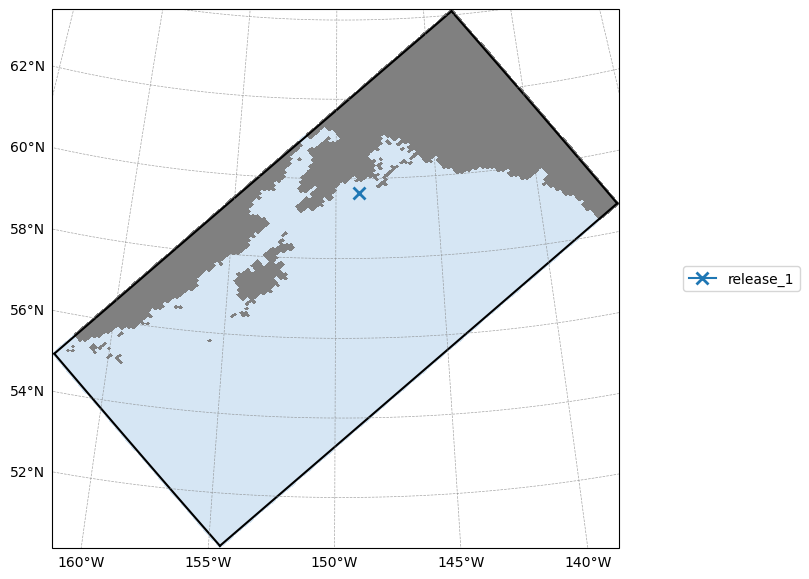

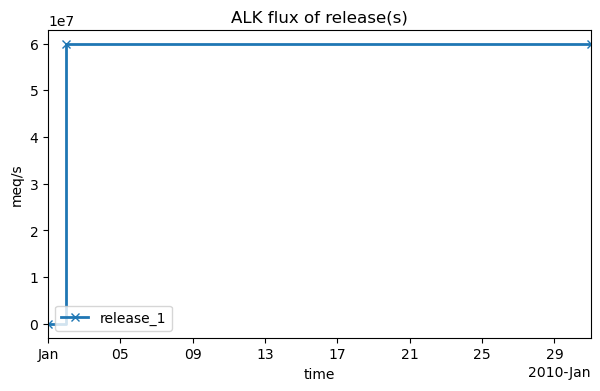

In [5]:
cdr = rt.CDRForcing(
    grid=rt.Grid(**grid_settings), # for plotting, could omit
    start_time=start_time,
    end_time=end_time,
    releases=[cdr_tracer_release1,],
)

cdr.plot_locations()
cdr.plot_tracer_flux("ALK")

# Generate the cdr information as a dict
cdr_as_dict = cdr.model_dump()["CDRForcing"]

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Create the builder</h1>
    <p style="font-size: large; line-height: 1.45; margin: 0;">
A CstarSpecBuilder instance is created, using a pre-defined ROMS-MARBL model specification (a <b>ModelSpec</b> name, which contains settings to enable ROMS-MARBL features and compilation to match your inputs and environment, and comes from the catalog -- more to come on that), and start and end dates. </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
The builder takes these changeable options and pulls model <b>source data</b>, generates <b>forcing data</b>, and constructed <b>C-Star blueprints</b> which will run the ROMS model and ensure <b>scientific reproducability<b>:
</p>
</div>

Note: No catalog_root specified. Using internal cstar-forge catalog for ModelSpec and MachineSpec (default/example values).
      Blueprints will be written to: /Users/blsaenz/cstar-forge-data/catalog
      To use a custom catalog, set catalog_root=<path> when creating CstarSpecBuilder.
CstarSpecBuilder: planned NetCDF outputs
  - /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_grid.nc
  - /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_initial_conditions.nc
  - /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_surface-physics.nc
  - /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_surface-bgc.nc
  - /Users/blsaenz/cstar-forge-data/input-data/cson

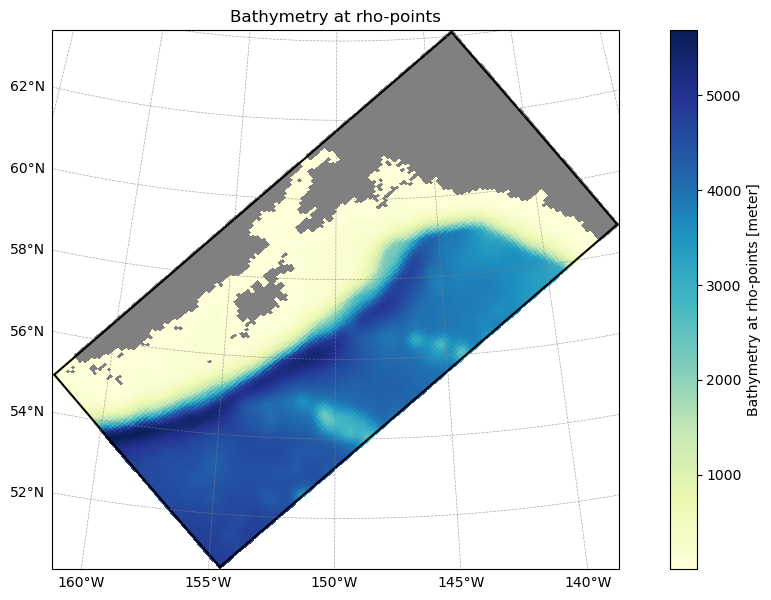

In [6]:
#Change to roms-tools grid gen, for plotting

# Model setup ------------------------------------------------------------------
model_spec = "cson_roms-marbl_v0.1"

partitioning = {
    "n_procs_x": 2, # number of partitions in xi (x) 
    "n_procs_y": 2, # number of partitions in eta (y) 
}

# Initialize CstarSpecBuilder --------------------------------------------------
builder = cstar_forge.CstarSpecBuilder(
    description="GulfOfAlaska_Demo",
    model_name=model_spec,
    grid_name=grid_name,
    grid_kwargs=grid_settings,
    open_boundaries=boundaries,    
    start_time=start_time,
    end_time=end_time,
    partitioning=partitioning,
    CDR_forcing=cdr_as_dict,
    #catalog_root = ...
)

builder.grid.plot()

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Forcing Data and Blueprint Generation</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star uses published datasets for ocean bathymetry, atmospheric variables, and initial and boundary conditions. These datasets are either steamable directly to C-Star or are staged online by C-Worthy. Souce data is used to re-grid and assemble initial conditions and forcing for the ROMS-MARBL model specified in the builder. The builder can then be used to generate blueprints and workplans that include generated inputs.  
</p></div>

In [7]:
# ensure that source data is staged locally
builder.ensure_source_data()

# prepare model input
builder.generate_inputs(clobber=False) # setting clobber=True will overwrite existing files

# configure and build the model blueprints
builder.configure_build()

✔️  Using existing GLORYS_REGIONAL file for 2009-12-31: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20091231.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-01: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100101.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-02: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100102.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-03: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100103.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-04: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100104.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-05: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100105.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-06: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100106.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-07: cmems_mod_glo_phy_my_0.083d

POSTCONFIG blueprint already exists at /Users/blsaenz/cstar-forge-data/catalog/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs/B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs_postconfig.yml. Create a new blueprint? [yes/no]:  yes


2026-05-30 13:43:49,035 [WARNING] - cdr_forcing.py:1063 - Grid not provided: cannot verify whether the specified lat/lon/depth location is within the domain or on land. Please check manually or provide a grid when instantiating the class.


🗑️  Deleted existing file: /Users/blsaenz/cstar-forge-data/catalog/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs/B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs_postconfig.yml
🗑️  Deleted existing file: /Users/blsaenz/cstar-forge-data/catalog/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs/settings_B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs_postconfig.yml
ℹ️  Input directory contains 13 .nc file(s): /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs
   (Continuing without clobber; per-step reuse follows the planned output list.)
ℹ️  Planned NetCDF outputs this run: 9; 9 already on disk (exact or stem match, e.g. *_0001.nc) — generation/save will be skipped for those.

▶️  [1/9] Writing ROMS grid...
   ↪ Reusing existing file: /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_grid.nc

▶️  [2/9] Generating initial conditions...
  

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Run ROMS-MARBL from Blueprint</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
Core C-Star functionality, like running a blueprint, is grouped into high-level commands </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we check the blueprint produced in the previous steps, and then compile and ROMS-MARBL and follow the blueprint to perform a model integration.</p>
</div>

In [11]:
%%time

builder.prep_cstar_environment(
   account_key = None,  # None gets from machine config or override here
   queue_name = None,  # None gets from machine config or override here
   walltime = "4:00:00",
   clobber = True,  # recommend True, but it will clear previous results from this run
   n_procs_available = 4,  # 0 is auto-detect, change if on a login or shared node to not overuse resources
)

# run the blueprint using on the command line
import os
os.environ["THIS_BP_PATH"] = str(builder.path_blueprint(stage="build"))
!echo $THIS_BP_PATH
!cstar blueprint run $THIS_BP_PATH 


/Users/blsaenz/cstar-forge-data/catalog/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs/B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_build.yml
2026-05-29 14:38:26,188 [INFO] - simulation.py:1288 - 🛠️ Configuring ROMSSimulation
2026-05-29 14:38:26,188 [INFO] - simulation.py:1291 - 🔧 Setting up ROMSExternalCodeBase...
2026-05-29 14:38:39,302 [INFO] - simulation.py:1291 - 🔧 Setting up MARBLExternalCodeBase...
2026-05-29 14:38:59,229 [INFO] - simulation.py:1305 - 📦 Fetching compile-time code...
2026-05-29 14:38:59,238 [INFO] - simulation.py:1310 - 📦 Fetching runtime code... 
2026-05-29 14:38:59,240 [INFO] - simulation.py:1315 - 📦 Fetching input datasets...
2026-05-29 14:38:59,267 [INFO] - input_dataset.py:97 - 🔗 Created symlink: /Users/blsaenz/cstar-forge-data/cstar-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_20100101-20100131/work/cdr.nc → /Users/blsaenz/cstar-forge-data/cstar-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_20100101-20100131/input/inp

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Analyze ROMS_MARBL output</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
After blueprint or workplan execution finishes, modeled results can be examined and summaried using ROMS-Tools </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we check the blueprint produced in the previous steps, and then compile and ROMS-MARBL and follow the blueprint to perform a model integration.</p>
</div>

/Users/blsaenz/cstar-forge-data/cstar-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs_20100101-20100131/joined_output/output_cdr.*.nc
First, Last output times:  2010-01-01T01:07:30.000000000 2010-01-31T00:00:00.000000000
[########################################] | 100% Completed | 120.13 ms
[########################################] | 100% Completed | 146.42 ms


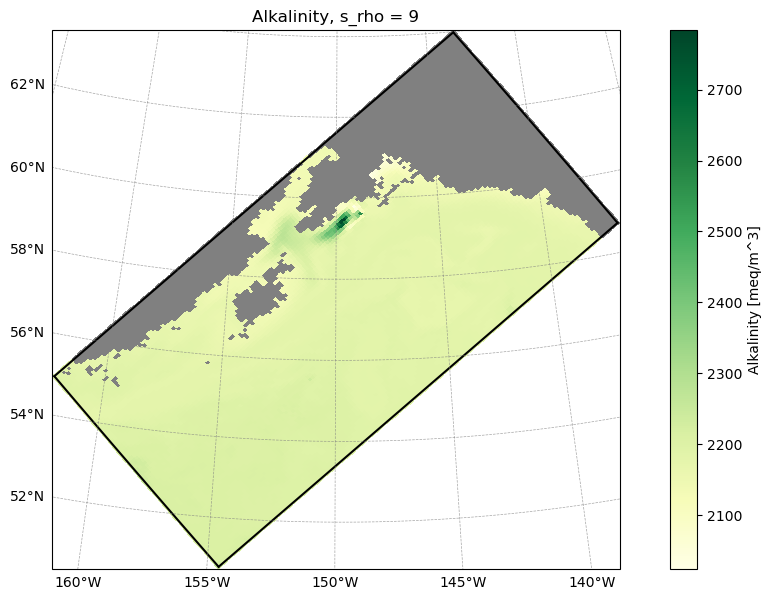

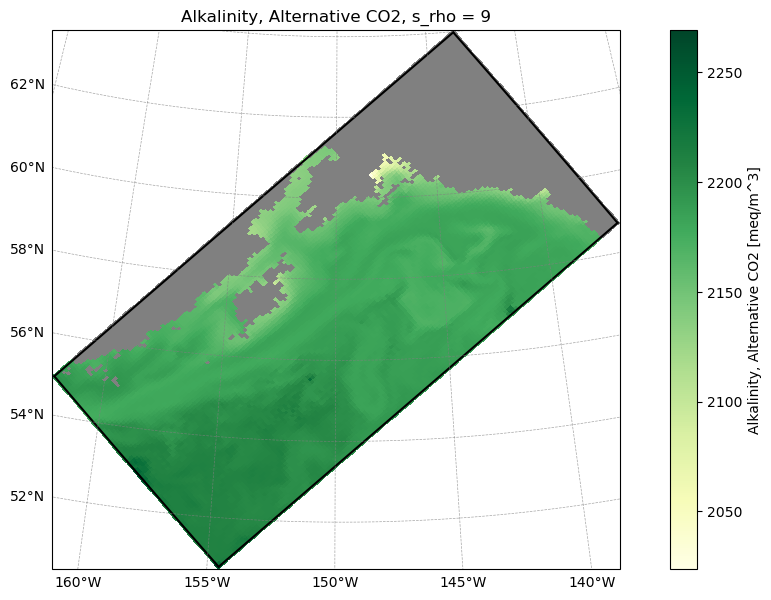

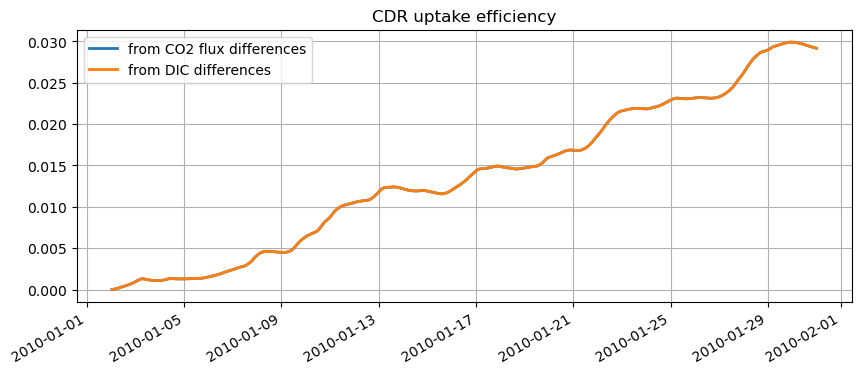

[########################################] | 100% Completed | 130.79 ms
[########################################] | 100% Completed | 123.79 ms
[########################################] | 100% Completed | 126.48 ms
[########################################] | 100% Completed | 127.08 ms
[########################################] | 100% Completed | 124.74 ms
[########################################] | 100% Completed | 123.97 ms
[########################################] | 100% Completed | 113.29 ms
[########################################] | 100% Completed | 113.59 ms
[########################################] | 100% Completed | 112.65 ms
[########################################] | 100% Completed | 113.21 ms
[########################################] | 100% Completed | 136.39 ms
[########################################] | 100% Completed | 134.12 ms
[########################################] | 100% Completed | 133.79 ms
[########################################] | 100% Completed | 13

In [17]:
import pandas as pd

print(builder.run_output_dir / "joined_output" / "output_cdr.*.nc")

cdr_output = rt.ROMSOutput(grid=builder.grid, path=builder.run_output_dir / "joined_output" / "output_cdr.*.nc", use_dask=True)

# full output is available as an xarray DataSet as cdr_output.ds
time_index = cdr_output.ds.time.values
print('First, Last output times: ',time_index[0],time_index[-1])

# ROMS-tools plotting is available for results
cdr_output.plot("ALK", time=-1, s=-1)
cdr_output.plot("ALK_ALT_CO2", time=-1, s=-1)
cdr_output.cdr_metrics()
cdr_output.create_movie(
    "ALK_source",
    time_range=slice(0, -1, 6),                # every 6 output (here, every six hours)
    fps=6,                                     # frames per second
    output_file="simulation_ALK_source.mp4",
    s=0,                                       # surface s=0
    include_boundary=True,                     # include boundary grid cells
    timestamp_xy=(0.05, 0.95)                  # display the time stamp at plot axes (x,y)
)


<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Domain Catalog</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
Scientifically verified domains and/or models will be available online in a [C]Worthy Domain Catalog. Domain catalogs are groupings of files (DomainSpec, ModelSpec, MachineSpec, and C-Star Blueprints) that together describe repropduceable model experiments. Domain catalogs can be created and hosted a local computer/filesstem, on Github, or elsewhere online.</p>
<br><p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we open a DomainCatalog using python, examine the DomainSpec and ModelSpec available, and use them to recreate a simulation.
</p>
</div>

In [8]:
cat = cstar_forge.DomainCatalog(catalog_root="https://github.com/CWorthy-ocean/CWorthy-Demo/catalog")
cat.tree()

ValueError: No valid catalog found at 'catalog'. Missing: ModelSpec/ (with at least one <name>/model.yml).
To initialize from the built-in package catalog run:
    DomainCatalog(catalog_root=..., initialize_catalog_from='local')
Or pass initialize_catalog_from=<inner-catalog-path> to copy from another existing catalog.

In [20]:
import pprint
pprint.pprint(cat.domain('ccs-12km'))

{'description': 'California Current System',
 'end_time': '2024-01-02',
 'grid_kwargs': {'N': 60,
                 'center_lat': 39.6,
                 'center_lon': -134.5,
                 'hc': 250.0,
                 'hmin': 5.0,
                 'nx': 224,
                 'ny': 440,
                 'rot': 33.3,
                 'size_x': 2688,
                 'size_y': 5280,
                 'theta_b': 6.0,
                 'theta_s': 6.0,
                 'verbose': True},
 'grid_name': 'ccs-12km',
 'model_name': 'cson_roms-marbl_v0.1',
 'open_boundaries': {'east': True, 'north': True, 'south': True, 'west': True},
 'partitioning': {'n_procs_x': 8, 'n_procs_y': 8},
 'start_time': '2024-01-01'}


In [ ]:
builder_ccs = cat.to_builder('ccs-12km',start_time='2010-01-01',end_time='2010-01-31')

In [ ]:
df = cat.blueprintDF()
df

In [ ]:
# run the remote blueprint (over http) using on the command line
import os
os.environ["BP_PATH"] = df.blueprint_path[0]
!echo $BP_PATH
!cstar blueprint run $BP_PATH